In [110]:
# Importación de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Fase 1: Exploracion y limpieza

EDA(Exploratory Data Analysis):

El Análisis Exploratorio de Datos se refiere al proceso de realizar una serie de investigaciones 
inciales sobre los datos que tenemos para poder descubrir patrones, detectar anomalías, probar hipótesis 
y comprobar suposiciones con la ayuda de estadísticas y representaciones gráficas.


## 1.1 Exploración inicial 

In [111]:
# En primer lugar, exploraremos el Customer Flight Activity, que lo denominaremos como df_cf
df_cfa = pd.read_csv("files/Customer Flight Activity.csv")
df_cfa.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [ ]:
#Lo primero que hacemos para mayor fluidez a la hora de analizar y buscar datos
df_cfa.columns = df_cfa.columns.str.lower().str.replace(" ", "_")

In [113]:
df_cfa.info()

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loyalty_number               405624 non-null  int64  
 1   year                         405624 non-null  int64  
 2   month                        405624 non-null  int64  
 3   flights_booked               405624 non-null  int64  
 4   flights_with_companions      405624 non-null  int64  
 5   total_flights                405624 non-null  int64  
 6   distance                     405624 non-null  int64  
 7   points_accumulated           405624 non-null  float64
 8   points_redeemed              405624 non-null  int64  
 9   dollar_cost_points_redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [114]:
df_cfa.describe().T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
flights_booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
flights_with_companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
total_flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
points_accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
points_redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
dollar_cost_points_redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


In [115]:
df_cfa.shape

(405624, 10)

In [116]:
df_cfa.columns

Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed'],
      dtype='str')

- Valores unicos

In [ ]:
df_cfa["loyalty_number"].value_counts()

loyalty_number
678205    72
101902    48
106001    48
112142    48
114414    48
          ..
998972    24
999304    24
999731    24
999788    24
999891    24
Name: count, Length: 16737, dtype: int64

In [161]:
df_cfa["points_accumulated"].value_counts()

points_accumulated
0.00      196128
180.00       763
270.00       734
288.00       717
189.00       709
           ...  
639.00         1
614.00         1
18.75          1
601.00         1
626.00         1
Name: count, Length: 1549, dtype: int64

In [118]:
df_cfa["year"].value_counts()

year
2017    202812
2018    202812
Name: count, dtype: int64

In [119]:
df_cfa["flights_booked"].value_counts()

flights_booked
0     197992
3      18228
11     15705
5      15084
7      14561
8      14357
9      14164
6      13847
2      13641
10     13363
4      12821
1      12667
13     10782
12     10382
14      7057
15      6582
16      4354
17      3899
18      2958
19      1496
20      1156
21       528
Name: count, dtype: int64

- Tipos de datos de las columnas

In [120]:
df_cfa.dtypes

loyalty_number                   int64
year                             int64
month                            int64
flights_booked                   int64
flights_with_companions          int64
total_flights                    int64
distance                         int64
points_accumulated             float64
points_redeemed                  int64
dollar_cost_points_redeemed      int64
dtype: object

- Comprobación de nulos

In [121]:
df_cfa.isnull().sum()

loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
dtype: int64

In [122]:
round(df_cfa.isnull().sum()/df_cfa.shape[0]*100,2)

loyalty_number                 0.0
year                           0.0
month                          0.0
flights_booked                 0.0
flights_with_companions        0.0
total_flights                  0.0
distance                       0.0
points_accumulated             0.0
points_redeemed                0.0
dollar_cost_points_redeemed    0.0
dtype: float64

In [123]:
df_cfa.notnull().sum()

loyalty_number                 405624
year                           405624
month                          405624
flights_booked                 405624
flights_with_companions        405624
total_flights                  405624
distance                       405624
points_accumulated             405624
points_redeemed                405624
dollar_cost_points_redeemed    405624
dtype: int64

- Comprobación de duplicados

In [124]:
#cantidad de filas duplicadas
df_cfa.duplicated().sum()

np.int64(1864)

In [126]:
df_cfa.duplicated(subset = "loyalty_number").sum()

np.int64(388887)

In [127]:
df_cfa.duplicated(subset = "year").sum()

np.int64(405622)

In [ ]:
round(df_cfa.duplicated().sum()/df_cfa.shape[0]*100,2)

np.float64(0.46)

In [128]:
# En segundo lugar, exploraremos el Customer Loyalty History, que lo denominaremos como df_cl
df_clh = pd.read_csv("files/Customer Loyalty History.csv")
df_clh.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [129]:
df_clh.columns = df_clh.columns.str.lower().str.replace(" ", "_")

In [130]:
df_clh.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loyalty_number      16737 non-null  int64  
 1   country             16737 non-null  str    
 2   province            16737 non-null  str    
 3   city                16737 non-null  str    
 4   postal_code         16737 non-null  str    
 5   gender              16737 non-null  str    
 6   education           16737 non-null  str    
 7   salary              12499 non-null  float64
 8   marital_status      16737 non-null  str    
 9   loyalty_card        16737 non-null  str    
 10  clv                 16737 non-null  float64
 11  enrollment_type     16737 non-null  str    
 12  enrollment_year     16737 non-null  int64  
 13  enrollment_month    16737 non-null  int64  
 14  cancellation_year   2067 non-null   float64
 15  cancellation_month  2067 non-null   float64
dtypes: float64(4), 

In [131]:
df_clh.shape

(16737, 16)

In [132]:
df_clh.columns

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month'],
      dtype='str')

- Valores unicos

In [157]:
df_clh["marital_status"].value_counts()

marital_status
Married     9735
Single      4484
Divorced    2518
Name: count, dtype: int64

In [159]:
df_clh["education"].value_counts()

education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

In [158]:
df_clh["loyalty_card"].value_counts()

loyalty_card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64

- Tipos de datos por columnas

In [167]:
df_clh.dtypes

loyalty_number          int64
country                   str
province                  str
city                      str
postal_code               str
gender                    str
education                 str
salary                float64
marital_status            str
loyalty_card              str
clv                   float64
enrollment_type           str
enrollment_year         int64
enrollment_month        int64
cancellation_year     float64
cancellation_month    float64
dtype: object

- Comprobación de nulos

In [133]:
df_clh.isnull().sum()

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                 4238
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64

In [134]:
round(df_clh.isnull().sum()/df_clh.shape[0]*100, 2)

loyalty_number         0.00
country                0.00
province               0.00
city                   0.00
postal_code            0.00
gender                 0.00
education              0.00
salary                25.32
marital_status         0.00
loyalty_card           0.00
clv                    0.00
enrollment_type        0.00
enrollment_year        0.00
enrollment_month       0.00
cancellation_year     87.65
cancellation_month    87.65
dtype: float64

In [135]:
df_clh.notnull().sum()

loyalty_number        16737
country               16737
province              16737
city                  16737
postal_code           16737
gender                16737
education             16737
salary                12499
marital_status        16737
loyalty_card          16737
clv                   16737
enrollment_type       16737
enrollment_year       16737
enrollment_month      16737
cancellation_year      2067
cancellation_month     2067
dtype: int64

- Comprobacion de duplicados

In [136]:
df_clh.duplicated().sum()

np.int64(0)

Observaciones 

df_cfa:
- Nulos ❌
- Duplicados ✅

Todos los datos están completos, pero hay registros repetidos

df_clh:
- Nulos ✅
- Duplicados ❌

Cada cliente es unico, pero hay datos faltantes

## 1.2 Limpieza de datos

- Tratamiento df_cfa:

Trataremos los duplicados

In [137]:
# Tratamiento de datos duplicados df_cfa:
# Se observa que los duplicados estan en pares identicos
df_cfa[df_cfa.duplicated(keep=False)]

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
41,101902,2017,1,0,0,0,0,0.0,0,0
42,101902,2017,1,0,0,0,0,0.0,0,0
226,112142,2017,1,0,0,0,0,0.0,0,0
227,112142,2017,1,0,0,0,0,0.0,0,0
477,126100,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
405111,971370,2018,12,0,0,0,0,0.0,0,0
405409,988392,2018,12,0,0,0,0,0.0,0,0
405410,988392,2018,12,0,0,0,0,0.0,0,0
405436,989528,2018,12,0,0,0,0,0.0,0,0


In [138]:
#vamos a quedarnos con 1 de cada par
df_cfa = df_cfa.drop_duplicates()

In [139]:
df_cfa.duplicated().sum()

np.int64(0)

- Tratamiento df_clh:

Trataremos los valores nulos

In [140]:
#Recordamos nuestro nulos
round(df_clh.isnull().sum()/df_clh.shape[0]*100, 2)


loyalty_number         0.00
country                0.00
province               0.00
city                   0.00
postal_code            0.00
gender                 0.00
education              0.00
salary                25.32
marital_status         0.00
loyalty_card           0.00
clv                    0.00
enrollment_type        0.00
enrollment_year        0.00
enrollment_month       0.00
cancellation_year     87.65
cancellation_month    87.65
dtype: float64

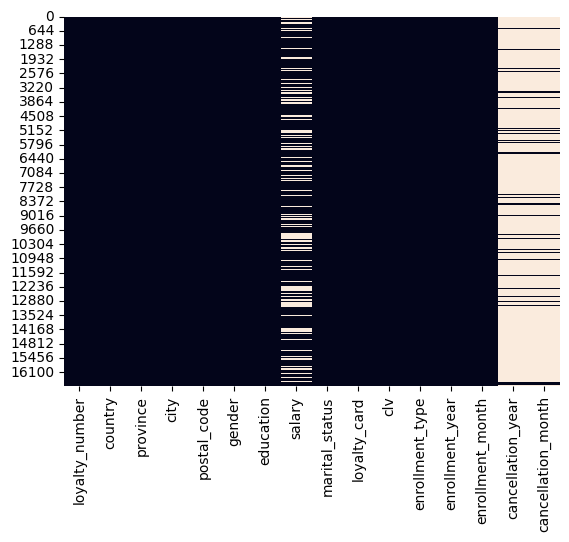

In [173]:
sns.heatmap(df_clh.isnull(), cbar=False)
plt.show()

Primero trataremos la variable "salary"

In [142]:
#Tratamiento de datos nulos en clh
#Observo que tengo salarios negativos
df_clh["salary"].describe().reset_index().T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
salary,12499.0,79245.609409,35008.297285,-58486.0,59246.5,73455.0,88517.5,407228.0


In [143]:
df_clh["salary"].median()

np.float64(73455.0)

In [144]:
df_clh["salary"].mean()

np.float64(79245.6094087527)

In [145]:
df_clh["salary"]

0         83236.0
1             NaN
2             NaN
3             NaN
4        103495.0
           ...   
16732         NaN
16733     89210.0
16734         NaN
16735    -57297.0
16736     75049.0
Name: salary, Length: 16737, dtype: float64

<Axes: xlabel='salary', ylabel='Count'>

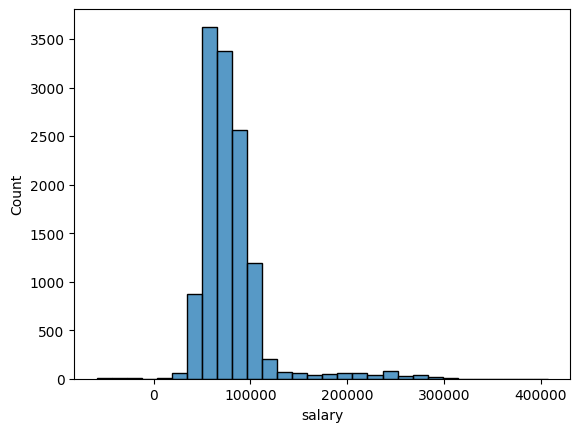

In [146]:
sns.histplot(data=df_clh, x="salary", bins=30)

<Axes: xlabel='salary'>

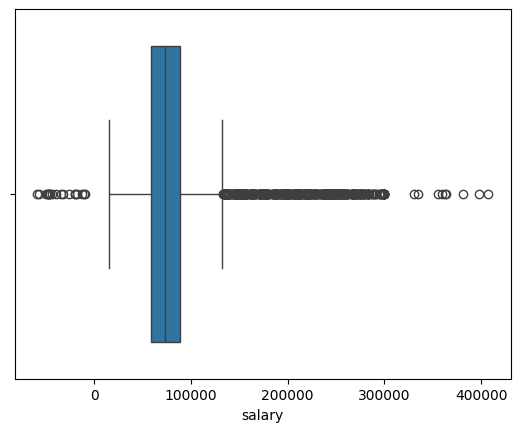

In [147]:
sns.boxplot(data=df_clh, x="salary")

In [148]:
df_clh[df_clh["salary"] < 0]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.0,Divorced,Star,24127.50,2018 Promotion,2018,3,NaN,NaN
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.0,Married,Aurora,9453.00,2018 Promotion,2018,3,NaN,NaN
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,3,NaN,NaN
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.0,Married,Star,2402.33,2018 Promotion,2018,3,NaN,NaN
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.0,Single,Star,2893.74,2018 Promotion,2018,3,NaN,NaN
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234.0,Married,Star,7597.91,2018 Promotion,2018,3,NaN,NaN
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.0,Married,Nova,5860.17,2018 Promotion,2018,4,NaN,NaN
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.0,Married,Nova,49423.80,2018 Promotion,2018,3,NaN,NaN
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.0,Married,Aurora,5067.21,2018 Promotion,2018,2,NaN,NaN
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.0,Married,Nova,2888.85,2018 Promotion,2018,2,NaN,NaN


In [150]:
(df_clh["salary"] < 0).sum()

np.int64(20)

In [151]:
round((df_clh["salary"] < 0).sum() / df_clh.shape[0] * 100, 2)

np.float64(0.12)

In [152]:
#vamos a convertir los datos negativos a positivos
df_clh["salary"] = df_clh["salary"].abs()

<Axes: xlabel='salary'>

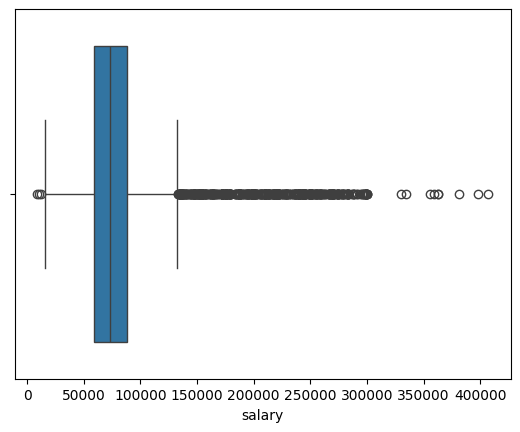

In [153]:
sns.boxplot(data=df_clh, x="salary")

In [154]:
(df_clh["salary"] < 0).sum()

np.int64(0)

In [155]:
#voy a ver filas donde salary es nulo
df_clh[df_clh["salary"].isnull()]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
6,927943,Canada,Ontario,Toronto,P5S 6R4,Female,College,NaN,Single,Star,3857.95,Standard,2014,6,NaN,NaN
13,988178,Canada,Quebec,Montreal,H4G 3T4,Male,College,NaN,Single,Star,3871.07,Standard,2013,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16721,632951,Canada,Alberta,Edmonton,T9G 1W3,Female,College,NaN,Married,Star,44771.30,Standard,2018,7,NaN,NaN
16727,546773,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Married,Star,52811.49,Standard,2015,9,NaN,NaN
16731,900501,Canada,Ontario,Sudbury,M5V 1G5,Male,College,NaN,Single,Star,61134.68,Standard,2012,9,NaN,NaN
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN


In [ ]:
Vamos a ver qué porcentaje de salarios está vacío en cada grupo

In [178]:
df_clh.groupby('education')['salary'].apply(lambda x: x.isna().mean())
#observamos un patrón claro y es que si alguien es college falta salary
# ¿Por qué TODOS los "College" no tienen salario?

education
Bachelor                0.0
College                 1.0
Doctor                  0.0
High School or Below    0.0
Master                  0.0
Name: salary, dtype: float64

In [182]:
df_clh[['education', 'salary']]

,education,salary
0,Bachelor,83236.0
1,College,NaN
2,College,NaN
3,College,NaN
4,Bachelor,103495.0
...,...,...
16732,College,NaN
16733,Bachelor,89210.0
16734,College,NaN
16735,Bachelor,57297.0


In [183]:
df_clh[df_clh['education'] == 'College'][['education', 'salary']]

,education,salary
1,College,NaN
2,College,NaN
3,College,NaN
6,College,NaN
13,College,NaN
...,...,...
16721,College,NaN
16727,College,NaN
16731,College,NaN
16732,College,NaN


In [185]:
df_clh['education'].value_counts(normalize=True) * 100

education
Bachelor                62.585888
College                 25.321145
High School or Below     4.672283
Doctor                   4.385493
Master                   3.035191
Name: proportion, dtype: float64

In [193]:
round(df_clh.isnull().sum()/df_clh.shape[0]*100, 2)

loyalty_number         0.00
country                0.00
province               0.00
city                   0.00
postal_code            0.00
gender                 0.00
education              0.00
salary                25.32
marital_status         0.00
loyalty_card           0.00
clv                    0.00
enrollment_type        0.00
enrollment_year        0.00
enrollment_month       0.00
cancellation_year     87.65
cancellation_month    87.65
dtype: float64

<Axes: xlabel='education', ylabel='salary'>

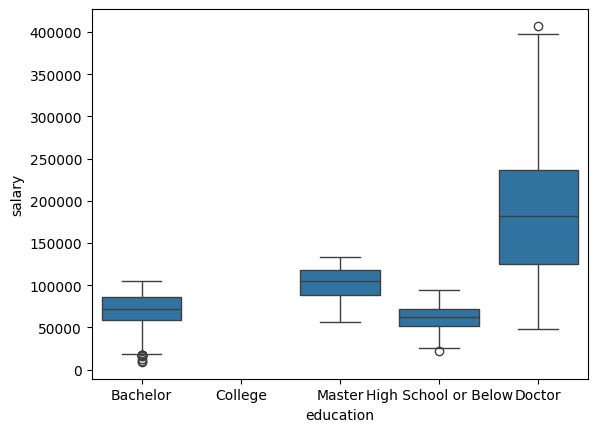

In [ ]:
sns.boxplot(data=df_clh, x='education', y='salary')
# Hay datos de salary para todos EXCEPTO College

- salary tiene 25.32% de nulos.
- College representa 25.32% del dataset.
- En College, salary está 100% vacío.

Los nulos de salary no son aleatorios, sino estructurales, ya que afectan por completo al grupo College. Por ello, no se considera apropiado imputarlos directamente en esta fase exploratoria, ya que podría introducir sesgo e inventar información no observada.

In [175]:
df_clh.groupby('loyalty_card')['salary'].apply(lambda x: x.isna().mean())

loyalty_card
Aurora    0.231554
Nova      0.234879
Star      0.276548
Name: salary, dtype: float64

In [176]:
df_clh.groupby('enrollment_type')['salary'].apply(lambda x: x.isna().mean())

enrollment_type
2018 Promotion    0.245108
Standard          0.253711
Name: salary, dtype: float64

In [171]:
df_clh.groupby('gender')['salary'].apply(lambda x: x.isna().mean())

gender
Female    0.247800
Male      0.258677
Name: salary, dtype: float64

In [190]:
df_clh[df_clh['education'] == 'College'].describe().T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,4238.0,549120.380132,255187.621974,100102.00,329815.250,547568.00,764847.7500,999982.00
salary,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clv,4238.0,7594.571756,6566.689430,1898.01,3750.265,5577.13,8501.2675,74228.52
enrollment_year,4238.0,2015.269467,1.962011,2012.00,2014.000,2015.00,2017.0000,2018.00
enrollment_month,4238.0,6.670363,3.438131,1.00,4.000,7.00,10.0000,12.00
cancellation_year,527.0,2016.571157,1.368495,2013.00,2016.000,2017.00,2018.0000,2018.00
cancellation_month,527.0,6.891841,3.332874,1.00,4.000,7.00,10.0000,12.00


In [191]:
df_clh[df_clh['education'] == 'College']['salary'].notna().sum()

np.int64(0)

Vamos a pasar a tratar los nulos de cancellation_year y month

In [197]:
# comprobamos que van juntos
(df_clh['cancellation_year'].isna() == df_clh['cancellation_month'].isna()).mean() * 100

np.float64(100.0)

In [196]:
df_clh[['cancellation_year', 'cancellation_month']]

,cancellation_year,cancellation_month
0,NaN,NaN
1,NaN,NaN
2,2018.0,1.0
3,NaN,NaN
4,NaN,NaN
...,...,...
16732,NaN,NaN
16733,NaN,NaN
16734,NaN,NaN
16735,NaN,NaN


Si hay año/mes -> el cliente no sigue en el programa "Inactivo"
Si aparece NaN -> el cliente sigue en el programa "Activo"

In [ ]:
df_clh['status_client'] = np.where(df_clh['cancellation_year'].isna(),'Activo','Inactivo')

In [201]:
df_clh['status_client']

0          Activo
1          Activo
2        Inactivo
3          Activo
4          Activo
           ...   
16732      Activo
16733      Activo
16734      Activo
16735      Activo
16736    Inactivo
Name: status_client, Length: 16737, dtype: str

In [204]:
df_clh['status_client'].value_counts(normalize=True).round(2)

status_client
Activo      0.88
Inactivo    0.12
Name: proportion, dtype: float64

In [206]:
df_clh = df_clh.drop(columns=['cancellation_year', 'cancellation_month'])

In [209]:
df_clh.head()

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,status_client
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,Activo
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,Inactivo
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,Activo
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,Activo


Los nulos de cancellation_year y cancellation_month no se consideran errores, sino ausencia de cancelación. Por ello, se transforman en una variable categórica status_cliente, donde Activo indica que el cliente no ha cancelado y Inactivo que sí lo ha hecho.

- Union de datos mediante merge puesto que tenemos la columna 'loyalty_number' en ambos df usandola como unión

In [210]:
df_unido = df_clh.merge(df_cfa, on='loyalty_number', how='left')

In [215]:
round(df_unido.isnull().sum()/df_unido.shape[0]*100, 2)

loyalty_number                  0.00
country                         0.00
province                        0.00
city                            0.00
postal_code                     0.00
gender                          0.00
education                       0.00
salary                         25.33
marital_status                  0.00
loyalty_card                    0.00
clv                             0.00
enrollment_type                 0.00
enrollment_year                 0.00
enrollment_month                0.00
status_client                   0.00
year                            0.00
month                           0.00
flights_booked                  0.00
flights_with_companions         0.00
total_flights                   0.00
distance                        0.00
points_accumulated              0.00
points_redeemed                 0.00
dollar_cost_points_redeemed     0.00
dtype: float64

Tras realizar la unión de ambos DataFrames mediante loyalty_number, se comprueba que no se generan nuevos valores nulos en las variables procedentes de la actividad de vuelos. La única variable que mantiene valores faltantes es salary, con un 25.33%, lo cual confirma que el problema de nulos ya estaba presente en el dataset de historial de clientes y no se debe al proceso de merge.

In [221]:
df_cfa.shape

(403760, 10)

In [223]:
df_clh.shape

(16737, 15)

In [212]:
df_unido.shape

(403760, 24)

In [219]:
df_unido.columns

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'status_client', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed'],
      dtype='str')